# LSTM

## Load data

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data

In [2]:
import pandas as pd
from pathlib import Path
from Modules.read_data import read_data

PRICE_ZONE = "DK1"  # "DK1" or "DK2"
TRAIN_WINDOW = 2 * 8760
VAL_START = "2024-01-01 00:00:00"
VAL_WINDOW = 8784
PREDICT_PERIOD = 4 * 168
STRIDE = 13 * 168                # Stride is measured from the start of the previous fold.
POST_VALIDATION_EXCLUDE_HOURS = 168  # Exclude first 168h after each validation window from remainder_2024_for_train
INCLUDE_REMAINING_2024_DURING_TRAINING = True
INCLUDE_DKPRICE_LAG1_AS_INPUT = True   # Add DKPrice_lag1 as an input feature
INCLUDE_PRICE_HISTORY_AS_INPUT = False   # Add actual DKPrice as an input feature (sets use_target_history=True)
INCLUDE_LAGS = False             # Include lag features (Price_lag1, Price_lag24, etc.) in training input
USE_FORECASTED_HISTORY = True    # Use model-predicted prices to compute lag features during prediction

(
    DK1_train,
    DK1_test,
    DK2_train,
    DK2_test,
    DK1_train_weather,
    DK1_test_weather,
    DK2_train_weather,
    DK2_test_weather
) = read_data("combined_data_cleaned_v5.csv")

if PRICE_ZONE == "DK1":
    dataset_train = DK1_train.copy()
    dataset_test = DK1_test.copy()
elif PRICE_ZONE == "DK2":
    dataset_train = DK2_train.copy()
    dataset_test = DK2_test.copy()
else:
    raise ValueError("PRICE_ZONE must be 'DK1' or 'DK2'.")

# read_data already returns all of 2024 in dataset_train and all of 2025 in dataset_test.
# Build the custom 2024 rolling validation split entirely from dataset_train.
dataset_train = dataset_train.sort_values("Time").reset_index(drop=True)
dataset_test = dataset_test.sort_values("Time").reset_index(drop=True)

val_start_ts = pd.Timestamp(VAL_START)
year_2024_start = pd.Timestamp("2024-01-01 00:00:00")
year_2025_start = pd.Timestamp("2025-01-01 00:00:00")

# Keep legacy full timeline variable before redefining dataset_train below.
df = pd.concat([dataset_train, dataset_test], ignore_index=True).sort_values("Time").reset_index(drop=True)

# Fixed history block: TRAIN_WINDOW ending at VAL_START.
history = dataset_train.loc[dataset_train["Time"] < val_start_ts].copy().iloc[-TRAIN_WINDOW:]
if len(history) < TRAIN_WINDOW:
    raise ValueError(
        f"Not enough history for TRAIN_WINDOW={TRAIN_WINDOW}. Got {len(history)} rows before {VAL_START}."
    )

data_2024 = dataset_train.loc[
    (dataset_train["Time"] >= year_2024_start) & (dataset_train["Time"] < year_2025_start)
].copy()

validation_idx = []
validation_windows = []
window_start = val_start_ts

# Validation windows in 2024: next fold starts STRIDE hours after the current fold start.
# Only full windows are allowed; trailing partial windows are skipped.
while (window_start + pd.Timedelta(hours=PREDICT_PERIOD)) <= year_2025_start:
    window_end = window_start + pd.Timedelta(hours=PREDICT_PERIOD)
    if window_end <= window_start:
        break

    mask = (data_2024["Time"] >= window_start) & (data_2024["Time"] < window_end)
    if mask.any():
        validation_idx.extend(data_2024.index[mask].tolist())
        validation_windows.append((window_start, window_end))

    window_start = window_start + pd.Timedelta(hours=STRIDE)

validation_idx = sorted(set(validation_idx))

# Exclude first POST_VALIDATION_EXCLUDE_HOURS after each validation window from train remainder.
post_validation_exclusion_idx = []
for _, window_end in validation_windows:
    exclusion_end = min(window_end + pd.Timedelta(hours=POST_VALIDATION_EXCLUDE_HOURS), year_2025_start)
    if exclusion_end <= window_end:
        continue

    exclusion_mask = (data_2024["Time"] >= window_end) & (data_2024["Time"] < exclusion_end)
    if exclusion_mask.any():
        post_validation_exclusion_idx.extend(data_2024.index[exclusion_mask].tolist())

post_validation_exclusion_idx = sorted(set(post_validation_exclusion_idx))
excluded_from_remainder_idx = sorted(set(validation_idx).union(post_validation_exclusion_idx))

dataset_validation = data_2024.loc[validation_idx].copy().sort_values("Time").reset_index(drop=True)
remainder_2024_for_train = data_2024.drop(index=excluded_from_remainder_idx).copy().sort_values("Time").reset_index(drop=True)

# Load cell is the only place that decides whether 2024 remainder is included in training.
if INCLUDE_REMAINING_2024_DURING_TRAINING:
    dataset_train = (
        pd.concat([history, remainder_2024_for_train], ignore_index=True)
        .sort_values("Time")
        .drop_duplicates(subset=["Time"], keep="last")
        .reset_index(drop=True)
    )
else:
    dataset_train = history.copy().sort_values("Time").reset_index(drop=True)

# Full context dataset: pre-2024 history + all of 2024.
# Used by get_predictions for lag computation regardless of training flags.
dataset_context = (
    pd.concat([history, data_2024], ignore_index=True)
    .sort_values("Time")
    .drop_duplicates(subset=["Time"], keep="last")
    .reset_index(drop=True)
)

# Preserve full target-bearing datasets for training/evaluation and create input views for later cells.
dataset_train_full = dataset_train.copy()
dataset_validation_full = dataset_validation.copy()
dataset_train_input = dataset_train_full.copy()
dataset_validation_input = dataset_validation_full.copy()

if not INCLUDE_PRICE_HISTORY_AS_INPUT:
    dataset_train_input = dataset_train_input.drop(columns=["DKPrice"])
    dataset_validation_input = dataset_validation_input.drop(columns=["DKPrice"])

lag_columns = [c for c in dataset_train_input.columns if '_lag' in c]
if not INCLUDE_LAGS:
    dataset_train_input = dataset_train_input.drop(columns=lag_columns, errors='ignore')
    dataset_validation_input = dataset_validation_input.drop(
        columns=[c for c in dataset_validation_input.columns if '_lag' in c], errors='ignore'
    )

# Add DKPrice_lag1 as a feature when INCLUDE_DKPRICE_LAG1_AS_INPUT is enabled.
# Computed from the full timeline (df) to handle training-set gaps correctly.
if INCLUDE_DKPRICE_LAG1_AS_INPUT:
    price_lag_full = df[["Time", "DKPrice"]].copy().sort_values("Time").reset_index(drop=True)
    price_lag_full["DKPrice_lag1"] = price_lag_full["DKPrice"].shift(1)
    price_lag_full = price_lag_full[["Time", "DKPrice_lag1"]]
    dataset_train_input = dataset_train_input.merge(price_lag_full, on="Time", how="left")
    dataset_validation_input = dataset_validation_input.merge(price_lag_full, on="Time", how="left")

# Keep 2025 as test set.
dataset_test = dataset_test.copy().reset_index(drop=True)

target_time = val_start_ts
prices = history["DKPrice"].astype(float).values.reshape(-1, 1)

def _load_feature_predictions_for_zone(zone):
    prediction_path = Path(project_root) / "Data" / f"feature_predictions_{zone}_2024-2025.csv"
    if not prediction_path.exists():
        print("No precomputed forecasts found.")
        return None

    predictions = pd.read_csv(prediction_path, sep=";", decimal=".", parse_dates=["Time"], dayfirst=True)
    predictions = predictions.loc[:, ~predictions.columns.duplicated()].copy()
    if "DKZone" in predictions.columns:
        predictions = predictions.loc[predictions["DKZone"] == zone].copy()
        print(f"Loaded {len(predictions)} forecasts for zone {zone}.")
        print(f"Forecast features: {len(predictions.columns)} {predictions.columns.tolist()}")
    return predictions

print(f"Using zone: {PRICE_ZONE}")
print(f"Train source shape (all of 2024): {DK1_train.shape if PRICE_ZONE == 'DK1' else DK2_train.shape}")
print(f"Test source shape (all of 2025): {DK1_test.shape if PRICE_ZONE == 'DK1' else DK2_test.shape}")
print(f"Include remainder_2024_for_train in training: {INCLUDE_REMAINING_2024_DURING_TRAINING}")
print(f"Include DKPrice_lag1 as input feature: {INCLUDE_DKPRICE_LAG1_AS_INPUT}")
print(f"Include DKPrice as input feature (use_target_history): {INCLUDE_PRICE_HISTORY_AS_INPUT}")
print(f"Include lag features in training input: {INCLUDE_LAGS}")
print(f"Use forecasted prices for lag computation during prediction: {USE_FORECASTED_HISTORY}")
print(f"Train shape (prepared training dataset): {dataset_train.shape}")
print(f"Training input shape: {dataset_train_input.shape}")
print(f"2024 remainder rows included in training: {len(remainder_2024_for_train) if INCLUDE_REMAINING_2024_DURING_TRAINING else 0}")
print(f"Validation shape (rolling 2024 windows): {dataset_validation.shape}")
print(f"Validation input shape: {dataset_validation_input.shape}")
print(f"Context shape (history + all 2024): {dataset_context.shape}")
print(f"Test shape (2025): {dataset_test.shape}")
print(f"Validation windows created: {len(validation_windows)}")
print(f"Post-validation exclusion hours: {POST_VALIDATION_EXCLUDE_HOURS}")
print(f"Rows excluded from remainder after validation windows: {len(post_validation_exclusion_idx)}")
if validation_windows:
    print("All validation windows:")
    for idx, (window_start, window_end) in enumerate(validation_windows, start=1):
        print(f"  {idx:02d}. {window_start} -> {window_end}")
print(f"Training dataset columns: {dataset_train.columns.tolist()}")
print(f"Training input columns: {dataset_train_input.columns.tolist()}")

feature_predictions = _load_feature_predictions_for_zone(PRICE_ZONE)    
if feature_predictions is not None:
    print("\nPrecomputed forecasts loaded.")

use_precomputed_feature_values = feature_predictions is not None

Notebook_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Modules
Python_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode
Data_folder: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Data
Training data shape (DK1): (78888, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78888, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%
Using zone: DK1
Train source shape (all of 2024): (78888, 38)
Test source shape (all of 2025): (8760, 38)
Include remainder_2024_for_train in training: True
Include DKPrice_lag1 as input feature: True
Include DKPrice as input feature (use_target_history): False
Include lag features in training input: False
Use forecasted prices for lag computation during prediction: True
Train shape (prepared training dataset): (22944, 38)
Training inpu

Load Random Forest forecasting models

In [3]:
from Modules.Load_RF_forecast_models import load_rf_models

rf_models = None
if not use_precomputed_feature_values:
    # load_rf_models currently supports only the optional timeout argument.
    rf_models = load_rf_models(user="Nikolaj")      # set user to "Nikolaj" or "Christine"

Test CUDA

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA DIAGNOSTICS")
print("\nBasic Info:")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"\nGPU Info:")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
    print(f"Device Count: {torch.cuda.device_count()}")

    test_tensor = torch.randn(100, 100).to(device)
    print(f"Tensor on CUDA: {test_tensor.is_cuda}")

else:
    print("\n  Running on CPU - no CUDA available")

CUDA DIAGNOSTICS

Basic Info:
CUDA available: True
Device: cuda

GPU Info:
GPU Name: NVIDIA GeForce RTX 5060 Ti
CUDA Version: 12.8
cuDNN Version: 91002
Device Count: 1
Tensor on CUDA: True


### Helper functions

In [4]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.base import BaseEstimator, RegressorMixin
from torch.utils.data import DataLoader, TensorDataset

def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def smape_mean(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.abs(y_true) + np.abs(y_pred)
    vals = np.where(denom == 0, 0.0, 200.0 * np.abs(y_pred - y_true) / denom)
    return float(np.mean(vals))

class TabularLSTM(nn.Module):
    """LSTM over true temporal windows: (batch, sequence_length, n_features)."""

    def __init__(self, input_size: int, hidden_size: int, layers: int, dropout: float = 0.0):
        super().__init__()
        self.dropout = float(dropout)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=layers,
            dropout=self.dropout if layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TorchLSTMRegressor(BaseEstimator, RegressorMixin):
    """Scikit-learn style regressor using configurable rolling time sequences."""

    def __init__(
        self,
        hidden_size: int = 32,
        layers: int = 1,
        learning_rate: float = 1e-3,
        epochs: int = 40,
        batch_size: int = 64,
        sequence_length: int = 24,
        dropout: float = 0.0,
        random_state: int = 42,
        log_epoch_metrics: bool = False,
        log_prefix: str = "",
        warm_start: bool = False,
        use_target_history: bool = True,
    ):
        self.hidden_size = hidden_size
        self.layers = layers
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.sequence_length = sequence_length
        self.dropout = dropout
        self.random_state = random_state
        self.log_epoch_metrics = log_epoch_metrics
        self.log_prefix = log_prefix
        self.warm_start = warm_start
        self.use_target_history = use_target_history

    def _to_tensor_sequence(self, X, y: np.ndarray | None = None, for_inference: bool = False):
        X_np = np.asarray(X, dtype=np.float32)
        if X_np.ndim != 2:
            raise ValueError(f"Expected X with shape (n_samples, n_features), got {X_np.shape}.")

        n_samples, n_features = X_np.shape
        seq_len = max(1, int(self.sequence_length))

        if n_samples == 0:
            raise ValueError("X is empty; cannot build sequences.")

        X_seq = np.empty((n_samples, seq_len, n_features + (2 if self.use_target_history else 0)), dtype=np.float32)

        # Left-pad with the first row so each timestamp gets a full sequence window.
        pad = np.repeat(X_np[:1], repeats=seq_len - 1, axis=0)
        padded = np.vstack([pad, X_np])

        if self.use_target_history:
            if (not for_inference) and y is None:
                raise ValueError("y must be provided during training when use_target_history=True.")

            y_hist = None if y is None else np.asarray(y, dtype=np.float32).reshape(-1)
            pred_hist = np.zeros(n_samples, dtype=np.float32)

            for i in range(n_samples):
                exog_window = padded[i : i + seq_len]
                target_window = np.zeros((seq_len, 1), dtype=np.float32)
                target_mask = np.zeros((seq_len, 1), dtype=np.float32)

                for j in range(seq_len):
                    idx = i - seq_len + 1 + j
                    if idx < 0:
                        continue
                    if idx < i:
                        if y_hist is not None:
                            target_window[j, 0] = y_hist[idx]
                        else:
                            target_window[j, 0] = pred_hist[idx]
                        target_mask[j, 0] = 1.0

                X_seq[i] = np.concatenate([exog_window, target_window, target_mask], axis=1)

                if for_inference:
                    with torch.no_grad():
                        x_i = torch.tensor(X_seq[i : i + 1], dtype=torch.float32).to(self.device_)
                        pred_hist[i] = float(self.model_(x_i).item())
        else:
            for i in range(n_samples):
                X_seq[i] = padded[i : i + seq_len]

        return torch.tensor(X_seq, dtype=torch.float32)

    def _initialize_model_state(self, input_size: int):
        self.device_ = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.pin_memory_ = self.device_.type == "cuda"
        self.input_size_ = int(input_size)
        self.model_ = TabularLSTM(
            input_size=self.input_size_,
            hidden_size=int(self.hidden_size),
            layers=int(self.layers),
            dropout=float(self.dropout),
        ).to(self.device_)
        self.loss_fn_ = nn.MSELoss()
        self.optimizer_ = torch.optim.Adam(self.model_.parameters(), lr=float(self.learning_rate))
        self.epoch_losses_ = []
        self.epoch_smapes_ = []
        self.epoch_maes_ = []
        self.epoch_rmses_ = []
        self._epochs_trained_ = 0

    def fit(self, X, y):
        set_seed(self.random_state)

        y_np = np.asarray(y, dtype=np.float32).reshape(-1, 1)
        X_tensor = self._to_tensor_sequence(X, y=y_np, for_inference=False)
        if len(y_np) != len(X_tensor):
            raise ValueError("X and y must have the same number of rows.")
        y_tensor = torch.tensor(y_np, dtype=torch.float32)

        needs_reinit = (
            (not bool(self.warm_start))
            or (not hasattr(self, "model_"))
            or (not hasattr(self, "input_size_"))
            or (int(self.input_size_) != int(X_tensor.shape[-1]))
        )
        if needs_reinit:
            self._initialize_model_state(input_size=int(X_tensor.shape[-1]))
        elif not hasattr(self, "device_"):
            self.device_ = next(self.model_.parameters()).device
            self.pin_memory_ = self.device_.type == "cuda"

        dataset_local = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset_local, batch_size=int(self.batch_size), shuffle=True, pin_memory=self.pin_memory_)

        self.model_.train()
        for _ in range(int(self.epochs)):
            batch_losses = []
            epoch_preds = []
            epoch_targets = []

            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.device_, non_blocking=self.pin_memory_)
                y_batch = y_batch.to(self.device_, non_blocking=self.pin_memory_)
                self.optimizer_.zero_grad()
                preds = self.model_(X_batch)
                loss = self.loss_fn_(preds, y_batch)
                loss.backward()
                self.optimizer_.step()

                batch_losses.append(float(loss.item()))
                epoch_preds.append(preds.detach().cpu().numpy().reshape(-1))
                epoch_targets.append(y_batch.detach().cpu().numpy().reshape(-1))

            epoch_loss = float(np.mean(batch_losses)) if batch_losses else float("nan")
            self.epoch_losses_.append(epoch_loss)

            if epoch_preds and epoch_targets:
                y_pred_epoch = np.concatenate(epoch_preds)
                y_true_epoch = np.concatenate(epoch_targets)
                epoch_smape = smape_mean(y_true_epoch, y_pred_epoch)
                epoch_mae = float(np.mean(np.abs(y_true_epoch - y_pred_epoch)))
                epoch_rmse = float(np.sqrt(np.mean((y_true_epoch - y_pred_epoch) ** 2)))
            else:
                epoch_smape = float("nan")
                epoch_mae = float("nan")
                epoch_rmse = float("nan")

            self.epoch_smapes_.append(float(epoch_smape))
            self.epoch_maes_.append(float(epoch_mae))
            self.epoch_rmses_.append(float(epoch_rmse))

            self._epochs_trained_ += 1

            if bool(self.log_epoch_metrics):
                try:
                    import wandb
                    if wandb.run is not None:
                        loss_name = f"{self.log_prefix}train_MSE_loss" if self.log_prefix else "train_MSE_loss"
                        smape_name = f"{self.log_prefix}train_smape" if self.log_prefix else "train_smape"
                        mae_name = f"{self.log_prefix}train_mae" if self.log_prefix else "train_mae"
                        rmse_name = f"{self.log_prefix}train_rmse" if self.log_prefix else "train_rmse"
                        epoch_name = f"{self.log_prefix}epoch" if self.log_prefix else "epoch"
                        wandb.log({
                            loss_name: epoch_loss,
                            smape_name: float(epoch_smape),
                            mae_name: float(epoch_mae),
                            rmse_name: float(epoch_rmse),
                            epoch_name: int(self._epochs_trained_),
                        })
                except Exception:
                    pass

        return self

    def predict(self, X):
        X_np = np.asarray(X, dtype=np.float32)
        if X_np.ndim == 2:
            self.model_.eval()
            X_tensor = self._to_tensor_sequence(X_np, y=None, for_inference=True)
        elif X_np.ndim == 3:
            X_tensor = torch.tensor(X_np, dtype=torch.float32)
        else:
            raise ValueError(f"Expected X with shape (n_samples, n_features) or (n_samples, sequence_length, n_features), got {X_np.shape}.")
        self.model_.eval()
        with torch.no_grad():
            X_tensor = X_tensor.to(self.device_, non_blocking=self.pin_memory_)
            preds = self.model_(X_tensor).squeeze(-1).detach().cpu().numpy()
        return preds


## Hyperparameter search

### Search

Search grid

In [10]:
import numpy as np

param_grid = {
    "hidden_size": [128],
    "layers": [4],
    "learning_rate": [0.00075, 0.00025],
    "max_epochs": [80],
    "patience": [30],
    "batch_size": [64],
    "sequence_length": [168],
    "dropout": [0.2, 0.3]
}

total_combinations = np.prod([len(v) for v in param_grid.values()])
if 1 in param_grid["layers"] and 0.0 in param_grid["dropout"] and len(param_grid["dropout"]) > 1:
    omitted_combinations = 1 / len(param_grid["layers"]) * 1 / len(param_grid["dropout"])
    total_combinations = total_combinations * (1 - omitted_combinations)

print("Total combinations:", total_combinations)

Total combinations: 4


Hyperparameter search

In [11]:

# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation3 import run_cross_validation
import itertools
from pathlib import Path
from time import time

import pandas as pd
import wandb

PREDICT_PERIOD = 1 * 168
split_setup = 2
start_combination = 1

WANDB_PROJECT = "LSTM_param_search_DK1_ExclLag_ExclPrice_InclLag1_Incl2024"

# WANDB_RUN_BASENAME is changed further down right before wandb.init to include param values
WANDB_RUN_BASENAME = f"{PRICE_ZONE}_LSTM_{TRAIN_WINDOW//8760}y_" + \
                    f"price{'incl' if INCLUDE_PRICE_HISTORY_AS_INPUT else 'excl'}_2024" + \
                    f"{'incl' if INCLUDE_REMAINING_2024_DURING_TRAINING else 'excl'}" + \
                    f"{'_lags_incl' if INCLUDE_LAGS else '_lags_excl'}" + \
                    f"_{PREDICT_PERIOD//168}val"

num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nActual number of combinations to test: {total_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

# Feature columns to use for training and prediction - derived from dataset_train_input
# which already respects INCLUDE_LAGS and INCLUDE_PRICE_HISTORY_AS_INPUT from the load cell.
cv_feature_columns = [c for c in dataset_train_input.columns if c not in ["Time", "DKPrice"]]
print(f"CV feature columns ({len(cv_feature_columns)}): {cv_feature_columns}")

start_time = time()
results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))
    if comb_number < start_combination:
        continue
    if int(params["layers"]) == 1 and float(params["dropout"]) > 0.0:
        continue

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")
    print(
        f"Time: {(time() - start_time)/60:.2f} minutes - estimated total time: "
        f"{(time() - start_time)/comb_number*num_combinations/60:.2f} minutes"
    )
    WANDB_RUN_BASENAME = f"layers{params['layers']}_dropout{params['dropout']}" + \
                        f"_batchsize{params['batch_size']}_seq_len{params['sequence_length']}" + \
                        f"_hidden{params['hidden_size']}_lr{params['learning_rate']}"
    
    run_name = f"{WANDB_RUN_BASENAME}_comb{comb_number:03d}"
    run = wandb.init(
        project=WANDB_PROJECT,
        name=run_name,
        config={
            "price_zone": PRICE_ZONE,
            "train_window": TRAIN_WINDOW,
            "val_window": VAL_WINDOW,
            "val_start": VAL_START,
            "predict_period": PREDICT_PERIOD,
            "stride": STRIDE,
            "split_setup": split_setup,
            "combination": int(comb_number),
            "num_combinations": int(num_combinations),
            "include_price_history_as_input": bool(INCLUDE_PRICE_HISTORY_AS_INPUT),
            "include_remaining_2024_in_prepared_train_data": bool(INCLUDE_REMAINING_2024_DURING_TRAINING),
            **params,
        },
        tags=["lstm", "hyperparameter-search", "cross-validation", "early-stopping"],
        reinit=True,
        settings=wandb.Settings(start_method="thread"),
    )

    try:
        max_epochs = int(params["max_epochs"])
        patience = int(params["patience"])

        model = TorchLSTMRegressor(
            hidden_size=int(params["hidden_size"]),
            layers=int(params["layers"]),
            learning_rate=float(params["learning_rate"]),
            epochs=1,
            batch_size=int(params["batch_size"]),
            sequence_length=int(params["sequence_length"]),
            dropout=float(params["dropout"]),
            random_state=42,
            warm_start=True,
            use_target_history=INCLUDE_PRICE_HISTORY_AS_INPUT,
        )

        best_val_smape = float("inf")
        best_epoch = 0
        patience_counter = 0
        best_combination_results = None

        lag_columns_in_input = [c for c in cv_feature_columns if "_lag" in c.lower()]
        price_columns_in_input = [
            c for c in cv_feature_columns
            if c == "DKPrice" or "price" in c.lower()
        ]

        print("\n========== Hyperparameter search input-feature check ==========")

        print(f"INCLUDE_LAGS flag: {INCLUDE_LAGS}")
        print(f"INCLUDE_PRICE_HISTORY_AS_INPUT flag: {INCLUDE_PRICE_HISTORY_AS_INPUT}")
        print(f"USE_FORECASTED_HISTORY flag: {USE_FORECASTED_HISTORY}")
        print(f"INCLUDE_REMAINING_2024_DURING_TRAINING flag: {INCLUDE_REMAINING_2024_DURING_TRAINING}")

        print("Train rows:", len(dataset_train))
        print("Train start:", dataset_train["Time"].min())
        print("Train end:", dataset_train["Time"].max())
        print("2024 rows in train:", (dataset_train["Time"].dt.year == 2024).sum())
        print("Val rows:", len(dataset_validation))
        print("Val start:", dataset_validation["Time"].min())
        print("Val end:", dataset_validation["Time"].max())

        print(f"\nNumber of input features: {len(cv_feature_columns)}")

        print("\nIs current DKPrice included in feature columns?")
        print("DKPrice" in cv_feature_columns)
        print("\nIs DKPrice included in model training?")
        print("model.use_target_history:", getattr(model, "use_target_history", None))

        print("\nPrice-related input columns:")
        print(price_columns_in_input if price_columns_in_input else "None")

        print("\nLag input columns:")
        print(lag_columns_in_input if lag_columns_in_input else "None")

        print(f"\nAll input columns (except DKPrice): {len(cv_feature_columns)}")
        print(cv_feature_columns)

        print("===============================================================\n")
        

        for epoch in range(1, max_epochs + 1):
            print(f"  Epoch {epoch}/{max_epochs}")
            combination_results = run_cross_validation(
                model=model,
                dataset_train=dataset_train,
                dataset_validation=dataset_validation,
                dataset_context=dataset_context,
                feature_columns=cv_feature_columns,
                include_remaining_2024=INCLUDE_REMAINING_2024_DURING_TRAINING,
                dk_zone=PRICE_ZONE,
                split_setup=split_setup,
                train_window=TRAIN_WINDOW,
                val_window=VAL_WINDOW,
                val_start=VAL_START,
                predict_period=PREDICT_PERIOD,
                stride=STRIDE,
                use_scaler=True,
                print_fold_results=False,
                plot=False,
                rf_models=rf_models,
                use_precomputed_feature_values=use_precomputed_feature_values,
                precomputed_feature_predictions=feature_predictions,
                use_forecasted_history=USE_FORECASTED_HISTORY,
            )

            val_smape = float(combination_results["overall_avg_weekly_smape"])

            if val_smape < best_val_smape:
                best_val_smape = val_smape
                best_epoch = epoch
                best_combination_results = combination_results
                patience_counter = 0
            else:
                patience_counter += 1

            wandb.log({
                "combination": int(comb_number),
                "epoch": int(epoch),
                "train_window": int(TRAIN_WINDOW),
                "val_window": int(VAL_WINDOW),
                "predict_period": int(PREDICT_PERIOD),
                "hidden_size": int(params["hidden_size"]),
                "layers": int(params["layers"]),
                "learning_rate": float(params["learning_rate"]),
                "batch_size": int(params["batch_size"]),
                "sequence_length": int(params["sequence_length"]),
                "max_epochs": int(params["max_epochs"]),
                "patience": int(params["patience"]),
                "val_SMAPE": float(val_smape),
                "best_val_SMAPE": float(best_val_smape),
                "patience_counter": int(patience_counter),
            })

            if patience_counter >= patience:
                print("  Early stopping triggered.")
                break

        print(f"\n  best_val_SMAPE={best_val_smape:.3f}")

        if best_combination_results is None:
            raise RuntimeError("No validation results were produced for this combination.")

        row = {
            **params,
            "best_epoch": int(best_epoch),
            "epochs_trained": int(epoch),
            "price_zone": PRICE_ZONE,
            "train_window": str(TRAIN_WINDOW // 8760) + " years",
            "val_start": VAL_START.split(" ")[0],
            "avg_smape": best_val_smape,
            "avg_weekly_rmse": best_combination_results["overall_avg_weekly_rmse"],
            "avg_weekly_mae": best_combination_results["overall_avg_weekly_mae"],
            "avg_weekly_smape": best_combination_results["overall_avg_weekly_smape"],
            "avg_daily_rmse": best_combination_results["overall_avg_daily_rmse"],
            "avg_daily_mae": best_combination_results["overall_avg_daily_mae"],
            "avg_daily_smape": best_combination_results["overall_avg_daily_smape"],
            "avg_smape_day_1": best_combination_results["avg_smape_day_1"],
            "avg_smape_day_2": best_combination_results["avg_smape_day_2"],
            "avg_smape_day_3": best_combination_results["avg_smape_day_3"],
            "avg_smape_day_4": best_combination_results["avg_smape_day_4"],
            "avg_smape_day_5": best_combination_results["avg_smape_day_5"],
            "avg_smape_day_6": best_combination_results["avg_smape_day_6"],
            "avg_smape_day_7": best_combination_results["avg_smape_day_7"],
        }
        results.append(row)

        run.summary.update({
            "best_epoch": int(best_epoch),
            "best_val_smape": float(best_val_smape),
            "epochs_trained": int(epoch),
        })
    finally:
        wandb.finish()

results_df = pd.DataFrame(results).sort_values("avg_smape")

project_root = Path.cwd()
while project_root.name != "Speciale_Kode" and project_root.parent != project_root:
    project_root = project_root.parent

output_folder = project_root / "Deep learners" / "LSTM"
output_folder.mkdir(parents=True, exist_ok=True)

base_filename = f"{PRICE_ZONE}_lstm_multi_search_results"
filename = output_folder / f"{base_filename}.csv"
counter = 1
while filename.exists():
    filename = output_folder / f"{base_filename}_{counter}.csv"
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")
print(f"\nResults saved to: {filename}")
display(results_df.head(10))



Actual number of combinations to test: 4
CV feature columns (33): ['OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radiation', 'DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'GrossCon', 'TotalProduction', 'Year', 'Month', 'Day', 'WeekDay', 'Hour', 'OffshoreWindCapacity', 'OnshoreWindCapacity', 'SolarPowerCapacity', 'DKPrice_lag1']

Combination 1/4: {'hidden_size': 128, 'layers': 4, 'learning_rate': 0.00075, 'max_epochs': 80, 'patience': 30, 'batch_size': 64, 'sequence_length': 168, 'dropout': 0.2}
Time: 0.00 minutes - estimated total time: 0.00 minutes



========== Hyperparameter search input-feature check ==========
INCLUDE_LAGS flag: False
INCLUDE_PRICE_HISTORY_AS_INPUT flag: False
USE_FORECASTED_HISTORY flag: True
INCLUDE_REMAINING_2024_DURING_TRAINING flag: True
Train rows: 22944
Train start: 2022-01-01 00:00:00
Train end: 2024-12-31 23:00:00
2024 rows in train: 5424
Val rows: 2688
Val start: 2024-01-01 00:00:00
Val end: 2024-10-27 23:00:00

Number of input features: 33

Is current DKPrice included in feature columns?
False

Is DKPrice included in model training?
model.use_target_history: False

Price-related input columns:
['DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'DKPrice_lag1']

Lag input columns:
['DKPrice_lag1']

All input columns (except DKPrice): 33
['OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radia

batch_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_SMAPE,█▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
combination,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
hidden_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
layers,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
max_epochs,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
patience,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
patience_counter,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇██
+5,...



Combination 2/4: {'hidden_size': 128, 'layers': 4, 'learning_rate': 0.00075, 'max_epochs': 80, 'patience': 30, 'batch_size': 64, 'sequence_length': 168, 'dropout': 0.3}
Time: 9.74 minutes - estimated total time: 19.49 minutes



========== Hyperparameter search input-feature check ==========
INCLUDE_LAGS flag: False
INCLUDE_PRICE_HISTORY_AS_INPUT flag: False
USE_FORECASTED_HISTORY flag: True
INCLUDE_REMAINING_2024_DURING_TRAINING flag: True
Train rows: 22944
Train start: 2022-01-01 00:00:00
Train end: 2024-12-31 23:00:00
2024 rows in train: 5424
Val rows: 2688
Val start: 2024-01-01 00:00:00
Val end: 2024-10-27 23:00:00

Number of input features: 33

Is current DKPrice included in feature columns?
False

Is DKPrice included in model training?
model.use_target_history: False

Price-related input columns:
['DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'DKPrice_lag1']

Lag input columns:
['DKPrice_lag1']

All input columns (except DKPrice): 33
['OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radia

...


Combination 4/4: {'hidden_size': 128, 'layers': 4, 'learning_rate': 0.00025, 'max_epochs': 80, 'patience': 30, 'batch_size': 64, 'sequence_length': 168, 'dropout': 0.3}
Time: 39.46 minutes - estimated total time: 39.46 minutes



========== Hyperparameter search input-feature check ==========
INCLUDE_LAGS flag: False
INCLUDE_PRICE_HISTORY_AS_INPUT flag: False
USE_FORECASTED_HISTORY flag: True
INCLUDE_REMAINING_2024_DURING_TRAINING flag: True
Train rows: 22944
Train start: 2022-01-01 00:00:00
Train end: 2024-12-31 23:00:00
2024 rows in train: 5424
Val rows: 2688
Val start: 2024-01-01 00:00:00
Val end: 2024-10-27 23:00:00

Number of input features: 33

Is current DKPrice included in feature columns?
False

Is DKPrice included in model training?
model.use_target_history: False

Price-related input columns:
['DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'DKPrice_lag1']

Lag input columns:
['DKPrice_lag1']

All input columns (except DKPrice): 33
['OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radia

batch_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_SMAPE,█▇▇▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
combination,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
hidden_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
layers,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
max_epochs,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
patience,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
patience_counter,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▃▄▄▄▅▅▆▆▇▇▇██
+5,...



Results saved to: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Deep learners\LSTM\DK1_lstm_multi_search_results_12.csv


,hidden_size,layers,learning_rate,max_epochs,patience,batch_size,sequence_length,dropout,best_epoch,epochs_trained,...,avg_daily_rmse,avg_daily_mae,avg_daily_smape,avg_smape_day_1,avg_smape_day_2,avg_smape_day_3,avg_smape_day_4,avg_smape_day_5,avg_smape_day_6,avg_smape_day_7
0,128,4,0.00075,80,30,64,168,0.2,15,45,...,256.261722,220.951595,62.067587,64.382865,52.780552,38.205668,52.432869,56.448012,77.344981,92.878165
2,128,4,0.00025,80,30,64,168,0.2,43,73,...,256.295493,220.983051,62.067746,64.397409,52.793617,38.199806,52.432077,56.438414,77.339636,92.873260
1,128,4,0.00075,80,30,64,168,0.3,15,45,...,256.306169,220.992981,62.067795,64.401998,52.797740,38.197956,52.431827,56.435385,77.337948,92.871712
3,128,4,0.00025,80,30,64,168,0.3,43,73,...,256.318485,221.004427,62.067852,64.407288,52.802492,38.195823,52.431538,56.431893,77.336003,92.869927


## Train final model

In [12]:

import copy
import numpy as np
import pandas as pd
from pathlib import Path
import wandb
import tempfile
import joblib
from sklearn.preprocessing import StandardScaler
from Modules.Validation3 import run_cross_validation

# Train final model using the prepared training dataset from the data loading cell
# =====================================================================================
PREDICT_PERIOD = 4 * 168
MAX_EPOCHS = 100
PATIENCE = 30
MIN_DELTA = 0.0
WANDB_PROJECT = "LSTM final"
WANDB_RUN_NAME = f"{PRICE_ZONE}_LSTM_{TRAIN_WINDOW//8760}y_" + \
                    f"Mask{'Incl' if INCLUDE_PRICE_HISTORY_AS_INPUT else 'Excl'}_" + \
                    f"Lag1{'Incl' if INCLUDE_DKPRICE_LAG1_AS_INPUT else 'Excl'}_" + \
                    f"2024{'Incl' if INCLUDE_REMAINING_2024_DURING_TRAINING else 'Excl'}_" + \
                    f"{PREDICT_PERIOD//168}val_" + \
                    f"hidden{128}_layers{4}_bs{64}_seq{168}_drop{0.3}"
save_model_to_wandb = True
save_model_to_disk = False

required_globals = [
    "dataset_train",
    "dataset_train_input",
    "dataset_validation",
    "dataset_context",
    "INCLUDE_PRICE_HISTORY_AS_INPUT",
    "INCLUDE_REMAINING_2024_DURING_TRAINING",
    "INCLUDE_LAGS",
    "USE_FORECASTED_HISTORY",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise ValueError(
        f"Run the load data cell first. Missing prepared training variables: {missing_globals}"
    )

if dataset_train.empty:
    raise ValueError("Prepared dataset_train is empty; cannot train final model.")
if dataset_validation.empty:
    raise ValueError("dataset_validation is empty; cannot run final training with early stopping.")

# Feature columns are derived from dataset_train_input, which already respects
# INCLUDE_LAGS and INCLUDE_PRICE_HISTORY_AS_INPUT from the load cell.
feature_columns = [c for c in dataset_train_input.columns if c not in ["Time", "DKPrice"]]
if not feature_columns:
    raise ValueError("No feature columns found in dataset_train_input.")

params = {
    "hidden_size": 128,
    "layers": 4,
    "learning_rate": 0.0005,
    "batch_size": 64,
    "sequence_length": 168,
    "dropout": 0.3,
}

output_root = Path(project_root) / "Deep learners" / "LSTM"
output_root.mkdir(parents=True, exist_ok=True)

run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    config={
        "price_zone": PRICE_ZONE,
        "train_window": int(TRAIN_WINDOW),
        "training_rows": int(len(dataset_train)),
        "validation_rows": int(len(dataset_validation)),
        "train_start_time": str(dataset_train["Time"].min()),
        "train_end_time": str(dataset_train["Time"].max()),
        "val_start": VAL_START,
        "val_window": int(VAL_WINDOW),
        "predict_period": int(PREDICT_PERIOD),
        "stride": int(STRIDE),
        "include_price_history_as_input": bool(INCLUDE_PRICE_HISTORY_AS_INPUT),
        "include_remaining_2024_in_prepared_train_data": bool(INCLUDE_REMAINING_2024_DURING_TRAINING),
        "include_lags": bool(INCLUDE_LAGS),
        "use_forecasted_history": bool(USE_FORECASTED_HISTORY),
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "save_model_to_wandb": bool(save_model_to_wandb),
        **params,
    },
    tags=["lstm", "final-model", "early-stopping"],
    reinit=True,
    settings=wandb.Settings(start_method="thread"),
)

print(f"Training rows: {len(dataset_train)}")
print(f"Training window: {dataset_train['Time'].min()} -> {dataset_train['Time'].max()}")
print(f"Validation rows: {len(dataset_validation)}")
print(f"Include remainder_2024_for_train: {INCLUDE_REMAINING_2024_DURING_TRAINING}")
print(f"Include DKPrice as input feature: {INCLUDE_PRICE_HISTORY_AS_INPUT}")
print(f"Include lag features: {INCLUDE_LAGS}")
print(f"Use forecasted history: {USE_FORECASTED_HISTORY}")
print(f"Feature columns ({len(feature_columns)}): {feature_columns}")

# Warm-start model: 1 epoch per call, early stopping in outer loop
model = TorchLSTMRegressor(
    hidden_size=int(params["hidden_size"]),
    layers=int(params["layers"]),
    learning_rate=float(params["learning_rate"]),
    epochs=1,
    batch_size=int(params["batch_size"]),
    sequence_length=int(params["sequence_length"]),
    dropout=float(params["dropout"]),
    random_state=42,
    log_epoch_metrics=True,
    log_prefix="final_",
    warm_start=True,
    use_target_history=INCLUDE_PRICE_HISTORY_AS_INPUT,
)

best_val_smape = float("inf")
best_epoch = 0
patience_counter = 0
best_model = None
epoch_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{MAX_EPOCHS}")

    epoch_results = run_cross_validation(
        model=model,
        dataset_train=dataset_train,
        dataset_validation=dataset_validation,
        dataset_context=dataset_context,
        feature_columns=feature_columns,
        include_remaining_2024=INCLUDE_REMAINING_2024_DURING_TRAINING,
        dk_zone=PRICE_ZONE,
        split_setup=2,
        train_window=TRAIN_WINDOW,
        val_window=VAL_WINDOW,
        val_start=VAL_START,
        predict_period=PREDICT_PERIOD,
        stride=STRIDE,
        use_scaler=True,
        print_fold_results=False,
        plot=False,
        rf_models=rf_models,
        use_precomputed_feature_values=use_precomputed_feature_values,
        precomputed_feature_predictions=feature_predictions,
        use_forecasted_history=USE_FORECASTED_HISTORY,
    )

    train_mse = float(model.epoch_losses_[-1]) if hasattr(model, "epoch_losses_") else float("nan")
    train_smape = float(model.epoch_smapes_[-1]) if hasattr(model, "epoch_smapes_") else float("nan")
    val_smape = float(epoch_results["overall_avg_weekly_smape"])
    val_mse = float(epoch_results["overall_avg_weekly_rmse"]) ** 2

    improved = val_smape < (best_val_smape - MIN_DELTA)
    if improved:
        best_val_smape = val_smape
        best_epoch = epoch
        patience_counter = 0
        best_model = copy.deepcopy(model)
        print(f"  Validation SMAPE improved: {val_smape:.4f} (best so far)")
    else:
        patience_counter += 1
        print(f"  Validation SMAPE: {val_smape:.4f} (patience {patience_counter}/{PATIENCE})")

    epoch_row = {
        "epoch": epoch,
        "train_MSE": train_mse,
        "train_SMAPE": train_smape,
        "val_SMAPE": val_smape,
        "best_val_SMAPE": best_val_smape,
        "patience_counter": int(patience_counter),
    }
    epoch_history.append(epoch_row)
    wandb.log(epoch_row)

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}. Best epoch: {best_epoch}.")
        break

if best_epoch == 0:
    raise RuntimeError("No valid epoch found during final training with early stopping.")

print(f"\n=== Final Training Complete ===")
print(f"Best epoch: {best_epoch}")
print(f"Best validation SMAPE: {best_val_smape:.4f}")

final_model = best_model

epoch_metrics_df = pd.DataFrame(epoch_history)
wandb.log({"final_epoch_metrics": wandb.Table(dataframe=epoch_metrics_df)})
wandb.log({
    "best_epoch": int(best_epoch),
    "best_val_smape": float(best_val_smape),
})
run.summary.update({
    "best_epoch": int(best_epoch),
    "best_val_smape": float(best_val_smape),
    "epochs_trained": int(epoch),
})

if save_model_to_wandb:
    model_artifact = wandb.Artifact(name=f"{WANDB_RUN_NAME}_model", type="model")
    with tempfile.TemporaryDirectory() as tmpdir:
        model_path = Path(tmpdir) / f"{WANDB_RUN_NAME}_model.joblib"
        joblib.dump(final_model, model_path, compress=3)
        model_artifact.add_file(str(model_path), name="model.joblib")
        run.log_artifact(model_artifact)
    print("Model stored in W&B artifact.")
else:
    print("Model not saved to W&B. Set save_model_to_wandb = True to upload it.")

print(f"Trained final model on the prepared {PRICE_ZONE} train set with early stopping (best epoch: {best_epoch}).")

wandb.finish()


Training rows: 22944
Training window: 2022-01-01 00:00:00 -> 2024-12-31 23:00:00
Validation rows: 2688
Include remainder_2024_for_train: True
Include DKPrice as input feature: False
Include lag features: False
Use forecasted history: True
Feature columns (33): ['OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radiation', 'DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'GrossCon', 'TotalProduction', 'Year', 'Month', 'Day', 'WeekDay', 'Hour', 'OffshoreWindCapacity', 'OnshoreWindCapacity', 'SolarPowerCapacity', 'DKPrice_lag1']

Epoch 1/100
Model trained in 4.13s. Now validating on 4 folds...

Average SMAPE across all weeks in all folds: 171.212
  Validation SMAPE improved: 171.2120 (best so far)

Epoch 2/100
Model trained in 4.13s. Now validating on 4 folds...

Average SMAPE 

best_epoch,▁
best_val_SMAPE,█▅▅▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_smape,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇███
final_epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇███
final_train_MSE_loss,██▇▇▆▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
final_train_mae,█▇▇▇▇▆▆▆▅▅▅▅▅▅▅▅▄▄▄▄▅▅▅▅▅▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
final_train_rmse,████▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
final_train_smape,██▆▆▆▅▅▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁
patience_counter,▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▅▅▆▆▇▇▁▁▂▃▃▄▄▅▅▅▅▆▆▇▇██
+3,...


Test Final Model

In [9]:

import numpy as np
import pandas as pd
from pathlib import Path
import wandb
import joblib
from sklearn.preprocessing import StandardScaler
from Modules.Validation3 import _build_validation_folds
from Modules.week_predictions2 import get_predictions

# =====================================================================================
# Test final model on 2025 only, week-by-week (168h blocks)
# =====================================================================================
WANDB_PROJECT = "LSTM final"
# WANDB_RUN_NAME = WANDB_RUN_NAME  # Must match final training run name
WANDB_RUN_NAME = "DK1_LSTM_2y_MaskExcl_Lag1Incl_2024Incl_4val_hidden64_layers3_bs64_seq24_drop0.2"
WANDB_TEST_RUN_NAME = f"{WANDB_RUN_NAME}_test"
WANDB_ARTIFACT_NAME = f"{WANDB_RUN_NAME}_model"


FORECAST_HORIZON = 168  # 1 week
PREDICT_PERIOD = 168    # one week per validation fold
STRIDE = 168            # next fold starts next week
TEST_START = pd.Timestamp("2025-01-01 00:00:00")
TEST_WINDOW = 8760
TEST_END = TEST_START + pd.Timedelta(hours=TEST_WINDOW - 1)

# Retrieve zone data
if PRICE_ZONE == "DK1":
    test_source = DK1_test.copy() if "DK1_test" in globals() else None
    history_source = DK1_train.copy() if "DK1_train" in globals() else None
elif PRICE_ZONE == "DK2":
    test_source = DK2_test.copy() if "DK2_test" in globals() else None
    history_source = DK2_train.copy() if "DK2_train" in globals() else None
else:
    raise ValueError("PRICE_ZONE must be 'DK1' or 'DK2'.")

if test_source is None or history_source is None:
    raise ValueError(f"Missing train/test source data for {PRICE_ZONE}. Run data loading first.")

test_source = test_source.sort_values("Time").reset_index(drop=True)
history_source = history_source.sort_values("Time").reset_index(drop=True)

# Test only on 2025 window requested by user
test_set = test_source.loc[
    (test_source["Time"] >= TEST_START) & (test_source["Time"] <= TEST_END)
].copy().sort_values("Time").reset_index(drop=True)

if len(test_set) != TEST_WINDOW:
    raise ValueError(
        f"Expected exactly TEST_WINDOW={TEST_WINDOW} rows from {TEST_START} to {TEST_END}, got {len(test_set)}."
    )

# Use the same feature columns the model was trained on (respects INCLUDE_LAGS and INCLUDE_PRICE_HISTORY_AS_INPUT)
feature_columns = [c for c in dataset_train_input.columns if c not in ["Time", "DKPrice"]]
if not feature_columns:
    raise ValueError("No feature columns found in dataset_train_input. Run the load data cell first.")

# Include end-of-2024 history so first 2025 prediction can build sequence/lag features.
# get_predictions expects DKPrice as the first column (target), followed by Time and features.
full_eval_dataset = (
    pd.concat([history_source, test_set], ignore_index=True)
    .sort_values("Time")
    .drop_duplicates(subset=["Time"], keep="last")
    .reset_index(drop=True)
)
# Compute DKPrice_lag1 if the model was trained with it as a feature.
if "DKPrice_lag1" in feature_columns:
    full_eval_dataset["DKPrice_lag1"] = full_eval_dataset["DKPrice"].shift(1)
missing_in_eval = [c for c in feature_columns if c not in full_eval_dataset.columns]
if missing_in_eval:
    raise ValueError(f"full_eval_dataset is missing feature columns from dataset_train_input: {missing_in_eval}")
# DKPrice must be the first column so get_predictions treats it as the target
full_eval_dataset = full_eval_dataset[["DKPrice", "Time"] + feature_columns].copy()

# Initialize W&B run
try:
    wandb.finish()
except Exception:
    pass
test_run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_TEST_RUN_NAME,
    job_type="evaluation",
    config={
        "price_zone": PRICE_ZONE,
        "test_start": str(TEST_START),
        "test_end": str(TEST_END),
        "test_window": int(TEST_WINDOW),
        "test_rows": int(len(test_set)),
        "model_artifact": WANDB_ARTIFACT_NAME,
        "forecast_horizon": int(FORECAST_HORIZON),
        "predict_period": int(PREDICT_PERIOD),
        "stride": int(STRIDE),
        "prediction_method": "weekly_168h_autoregressive",
    },
    tags=["lstm", "final-model", "test", "evaluation", "weekly-metrics"],
    reinit=True,
    settings=wandb.Settings(start_method="thread"),
)

# Load trained model
model_artifact = test_run.use_artifact(f"{WANDB_ARTIFACT_NAME}:latest")
artifact_dir = Path(model_artifact.download())
model_path = artifact_dir / "model.joblib"
if not model_path.exists():
    raise ValueError(f"Could not find model.joblib in downloaded artifact: {artifact_dir}")

model = joblib.load(model_path)
print(f"Loaded model artifact: {WANDB_ARTIFACT_NAME}:latest")
print(f"Test window: {TEST_START} -> {TEST_END} ({len(test_set)} rows)")
print(f"Feature columns ({len(feature_columns)}): {feature_columns}")

# Fit scaler on the same training tail used during training.
# Compute target-lag columns on the full sorted history before taking the tail
# so that the first row of the tail has a valid lag value.
train_for_scaler = history_source.sort_values("Time").copy()
if "DKPrice_lag1" in feature_columns and "DKPrice_lag1" not in train_for_scaler.columns:
    train_for_scaler["DKPrice_lag1"] = train_for_scaler["DKPrice"].shift(1)
train_for_scaler = train_for_scaler.tail(TRAIN_WINDOW).reset_index(drop=True)
X_scaler = train_for_scaler[feature_columns].astype(np.float32)
scaler = StandardScaler()
scaler.fit(X_scaler)

# Build 2025 weekly folds
folds = _build_validation_folds(
    data=full_eval_dataset,
    val_window=TEST_WINDOW,
    val_start=str(TEST_START),
    predict_period=PREDICT_PERIOD,
    stride=STRIDE,
    validation_reference=test_set,
)
print(f"Generated {len(folds)} weekly folds with predict_period={PREDICT_PERIOD}, stride={STRIDE}.")

# Metric helper
def smape_mean(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.abs(y_true) + np.abs(y_pred)
    vals = np.where(denom == 0, 0.0, 200.0 * np.abs(y_pred - y_true) / denom)
    return float(np.mean(vals))

# Evaluate fold-by-fold (week-by-week)
all_week_evals = []
day_smapes_per_week = {}  # (fold_no, week_no) -> {day_num -> smape}

for fold in folds:
    fold_no = int(fold["fold"])
    fold_val_data = test_set.loc[
        (test_set["Time"] >= fold["val_start"]) & (test_set["Time"] <= fold["val_end"])
    ].copy()

    preds_by_week = get_predictions(
        model=model,
        dataset=full_eval_dataset,
        val_start=fold["val_start"],
        val_end=fold["val_end"],
        forecast_horizon=FORECAST_HORIZON,
        fitted_scaler=scaler,
        dk_zone=PRICE_ZONE,
        rf_models=rf_models if "rf_models" in globals() else None,
        use_precomputed_feature_values=use_precomputed_feature_values if "use_precomputed_feature_values" in globals() else False,
        precomputed_feature_predictions=feature_predictions if "feature_predictions" in globals() else None,
        use_forecasted_history=USE_FORECASTED_HISTORY,
    )

    for week_no, week_pred_df in preds_by_week.items():
        week_eval = week_pred_df.merge(
            fold_val_data[["Time", "DKPrice"]],
            on="Time",
            how="left",
        )
        week_eval = week_eval.dropna(subset=["DKPrice"]).copy()
        if week_eval.empty:
            continue

        week_eval["fold"] = fold_no
        week_eval["week_in_fold"] = int(week_no)
        all_week_evals.append(week_eval)

        week_key = (fold_no, int(week_no))
        day_smapes_per_week[week_key] = {}
        week_eval_sorted = week_eval.sort_values("Time").reset_index(drop=True)

        for day_num in range(1, 8):
            start_hour = (day_num - 1) * 24
            end_hour = day_num * 24
            day_data = week_eval_sorted.iloc[start_hour:end_hour]
            if len(day_data) > 0:
                day_smapes_per_week[week_key][day_num] = smape_mean(
                    day_data["DKPrice"].values,
                    day_data["Prediction"].values,
                )

if not all_week_evals:
    raise RuntimeError("No aligned predictions produced for 2025 weekly folds.")

results_df = pd.concat(all_week_evals, ignore_index=True).sort_values("Time").reset_index(drop=True)
results_df = results_df.rename(columns={"DKPrice": "Actual"})
results_df["Error"] = results_df["Actual"] - results_df["Prediction"]
results_df["Abs_Error"] = np.abs(results_df["Error"])

y_actual = results_df["Actual"].values
y_pred = results_df["Prediction"].values

# Overall metrics
overall_mse = float(np.mean((y_actual - y_pred) ** 2))
overall_smape = smape_mean(y_actual, y_pred)
overall_mae = float(np.mean(np.abs(y_actual - y_pred)))
overall_rmse = float(np.sqrt(overall_mse))

print("\n=== Overall Test Results ===")
print(f"MSE Loss:  {overall_mse:.6f}")
print(f"SMAPE:     {overall_smape:.6f}")
print(f"MAE:       {overall_mae:.6f}")
print(f"RMSE:      {overall_rmse:.6f}")

# Weekly metrics (calendar week)
print("\n=== Weekly Metrics ===")
results_df["Week"] = results_df["Time"].dt.isocalendar().week
weekly_results = []
for week, group in results_df.groupby("Week"):
    week_actual = group["Actual"].values
    week_pred = group["Prediction"].values
    week_rmse = float(np.sqrt(np.mean((week_actual - week_pred) ** 2)))
    week_mae = float(np.mean(np.abs(week_actual - week_pred)))
    week_smape = smape_mean(week_actual, week_pred)
    weekly_results.append({
        "week": int(week),
        "rmse": week_rmse,
        "mae": week_mae,
        "smape": week_smape,
        "n_samples": len(group),
    })
    print(f"Week {week:02d}: RMSE={week_rmse:.4f}, MAE={week_mae:.4f}, SMAPE={week_smape:.4f}")

# Daily metrics
print("\n=== Daily Metrics (by Date) ===")
results_df["Date"] = results_df["Time"].dt.date
daily_results = []
for date, group in results_df.groupby("Date"):
    day_actual = group["Actual"].values
    day_pred = group["Prediction"].values
    day_rmse = float(np.sqrt(np.mean((day_actual - day_pred) ** 2)))
    day_mae = float(np.mean(np.abs(day_actual - day_pred)))
    day_smape = smape_mean(day_actual, day_pred)
    daily_results.append({
        "date": str(date),
        "rmse": day_rmse,
        "mae": day_mae,
        "smape": day_smape,
        "n_samples": len(group),
    })
    print(f"{date}: RMSE={day_rmse:.4f}, MAE={day_mae:.4f}, SMAPE={day_smape:.4f}")

# Day-of-forecast metrics (Day 1..7 inside each predicted week)
print("\n=== Day-of-Forecast Metrics (within each 168-hour period) ===")
day_of_forecast_smapes = {}
for day_num in range(1, 8):
    smapes = [
        day_smapes_per_week[w].get(day_num)
        for w in day_smapes_per_week
        if day_num in day_smapes_per_week[w]
    ]
    smapes = [s for s in smapes if s is not None and not np.isnan(s)]
    day_of_forecast_smapes[day_num] = float(np.mean(smapes)) if smapes else float("nan")
    print(f"Day {day_num} (hours {(day_num-1)*24}-{day_num*24-1}): avg SMAPE={day_of_forecast_smapes[day_num]:.4f}")

# Average weekly/daily metrics
avg_weekly_rmse = float(np.mean([r["rmse"] for r in weekly_results]))
avg_weekly_mae = float(np.mean([r["mae"] for r in weekly_results]))
avg_weekly_smape = float(np.mean([r["smape"] for r in weekly_results]))

avg_daily_rmse = float(np.mean([r["rmse"] for r in daily_results]))
avg_daily_mae = float(np.mean([r["mae"] for r in daily_results]))
avg_daily_smape = float(np.mean([r["smape"] for r in daily_results]))

print("\n=== Average Weekly Metrics ===")
print(f"Avg Weekly RMSE: {avg_weekly_rmse:.6f}")
print(f"Avg Weekly MAE:  {avg_weekly_mae:.6f}")
print(f"Avg Weekly SMAPE: {avg_weekly_smape:.6f}")

print("\n=== Average Daily Metrics ===")
print(f"Avg Daily RMSE: {avg_daily_rmse:.6f}")
print(f"Avg Daily MAE:  {avg_daily_mae:.6f}")
print(f"Avg Daily SMAPE: {avg_daily_smape:.6f}")

# Save all hourly predictions to CSV
output_root = Path(project_root) / "Deep learners" / "LSTM"
output_root.mkdir(parents=True, exist_ok=True)
predictions_csv_path = output_root / f"{WANDB_RUN_NAME}_test_predictions.csv"
results_df.to_csv(predictions_csv_path, index=False, sep=";", decimal=".")
print(f"\nHourly predictions saved to: {predictions_csv_path}")

# Log metrics
test_run.log({
    "test_overall_MSE_loss": overall_mse,
    "test_overall_SMAPE": overall_smape,
    "test_overall_MAE": overall_mae,
    "test_overall_RMSE": overall_rmse,
    "test_avg_weekly_RMSE": avg_weekly_rmse,
    "test_avg_weekly_MAE": avg_weekly_mae,
    "test_avg_weekly_SMAPE": avg_weekly_smape,
    "test_avg_daily_RMSE": avg_daily_rmse,
    "test_avg_daily_MAE": avg_daily_mae,
    "test_avg_daily_SMAPE": avg_daily_smape,
    "test_avg_smape_day_1": day_of_forecast_smapes.get(1, float("nan")),
    "test_avg_smape_day_2": day_of_forecast_smapes.get(2, float("nan")),
    "test_avg_smape_day_3": day_of_forecast_smapes.get(3, float("nan")),
    "test_avg_smape_day_4": day_of_forecast_smapes.get(4, float("nan")),
    "test_avg_smape_day_5": day_of_forecast_smapes.get(5, float("nan")),
    "test_avg_smape_day_6": day_of_forecast_smapes.get(6, float("nan")),
    "test_avg_smape_day_7": day_of_forecast_smapes.get(7, float("nan")),
})

weekly_df = pd.DataFrame(weekly_results)
daily_df = pd.DataFrame(daily_results)
test_run.log({
    "test_weekly_metrics": wandb.Table(dataframe=weekly_df),
    "test_daily_metrics": wandb.Table(dataframe=daily_df),
    "test_predictions_sample": wandb.Table(dataframe=results_df.head(100)),
})

test_run.summary.update({
    "test_overall_MSE_loss": overall_mse,
    "test_overall_SMAPE": overall_smape,
    "test_overall_MAE": overall_mae,
    "test_overall_RMSE": overall_rmse,
    "test_avg_weekly_RMSE": avg_weekly_rmse,
    "test_avg_weekly_MAE": avg_weekly_mae,
    "test_avg_weekly_SMAPE": avg_weekly_smape,
    "test_avg_daily_RMSE": avg_daily_rmse,
    "test_avg_daily_MAE": avg_daily_mae,
    "test_avg_daily_SMAPE": avg_daily_smape,
    "test_samples": int(len(results_df)),
    "test_period_start": str(TEST_START),
    "test_period_end": str(TEST_END),
    "n_weeks": len(weekly_results),
    "n_days": len(daily_results),
})


print(f"\nTest predictions and metrics logged to W&B run: {WANDB_TEST_RUN_NAME}")
wandb.finish()


wandb:   1 of 1 files downloaded.  
c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\torch\nn\modules\rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.lstm(
c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\torch\nn\modules\rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\

Loaded model artifact: DK1_LSTM_2y_MaskExcl_Lag1Incl_2024Incl_4val_hidden64_layers3_bs64_seq24_drop0.2_model:latest
Test window: 2025-01-01 00:00:00 -> 2025-12-31 23:00:00 (8760 rows)
Feature columns (33): ['OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radiation', 'DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'GrossCon', 'TotalProduction', 'Year', 'Month', 'Day', 'WeekDay', 'Hour', 'OffshoreWindCapacity', 'OnshoreWindCapacity', 'SolarPowerCapacity', 'DKPrice_lag1']
Generated 52 weekly folds with predict_period=168, stride=168.


c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\torch\nn\modules\rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.lstm(
c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\torch\nn\modules\rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.


=== Overall Test Results ===
MSE Loss:  143963.794886
SMAPE:     57.091601
MAE:       282.688815
RMSE:      379.425612

=== Weekly Metrics ===
Week 01: RMSE=297.5850, MAE=233.6543, SMAPE=52.7675
Week 02: RMSE=329.1828, MAE=293.5843, SMAPE=56.5244
Week 03: RMSE=536.1000, MAE=370.2268, SMAPE=45.7133
Week 04: RMSE=710.4045, MAE=488.9903, SMAPE=60.4603
Week 05: RMSE=387.8749, MAE=341.0066, SMAPE=48.9898
Week 06: RMSE=372.2461, MAE=290.0302, SMAPE=37.8666
Week 07: RMSE=512.3554, MAE=407.1346, SMAPE=47.9226
Week 08: RMSE=349.3534, MAE=259.4709, SMAPE=37.6959
Week 09: RMSE=391.8085, MAE=346.2207, SMAPE=51.3260
Week 10: RMSE=351.4669, MAE=304.4351, SMAPE=71.1499
Week 11: RMSE=341.7116, MAE=283.9157, SMAPE=41.2901
Week 12: RMSE=430.7652, MAE=371.8853, SMAPE=81.6632
Week 13: RMSE=349.9515, MAE=282.5567, SMAPE=57.3694
Week 14: RMSE=377.1260, MAE=299.3596, SMAPE=66.4819
Week 15: RMSE=386.5553, MAE=326.6916, SMAPE=75.9821
Week 16: RMSE=285.8381, MAE=217.8186, SMAPE=48.3434
Week 17: RMSE=317.0393, 

test_avg_daily_MAE,▁
test_avg_daily_RMSE,▁
test_avg_daily_SMAPE,▁
test_avg_smape_day_1,▁
test_avg_smape_day_2,▁
test_avg_smape_day_3,▁
test_avg_smape_day_4,▁
test_avg_smape_day_5,▁
test_avg_smape_day_6,▁
test_avg_smape_day_7,▁
+7,...


Shap analysis

wandb:   1 of 1 files downloaded.  


Loaded LSTM model artifact: DK1_LSTM_2y_PricmaskExcl_PriceLag1Incl_2024Incl__4valhidden128_layers3_model:latest
Available RAM before SHAP: 13.92 GB
Unique eval hours requested: 300
Unique eval hours used: 300
Unique background hours used: 200
Window shape for SHAP: (300, 168, 33)
Grouped SHAP feature count: 33
Kernel SHAP nsamples: 100
SHAP chunk size: 20
Predict batch size: 8


c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\torch\nn\modules\rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.lstm(
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Computing SHAP chunk 1/15 (rows 0:20)...


100%|██████████| 20/20 [03:47<00:00, 11.35s/it]

...

Computing SHAP chunk 14/15 (rows 260:280)...


100%|██████████| 20/20 [03:44<00:00, 11.25s/it]


Computing SHAP chunk 15/15 (rows 280:300)...


100%|██████████| 20/20 [03:47<00:00, 11.35s/it]



SHAP analysis complete.


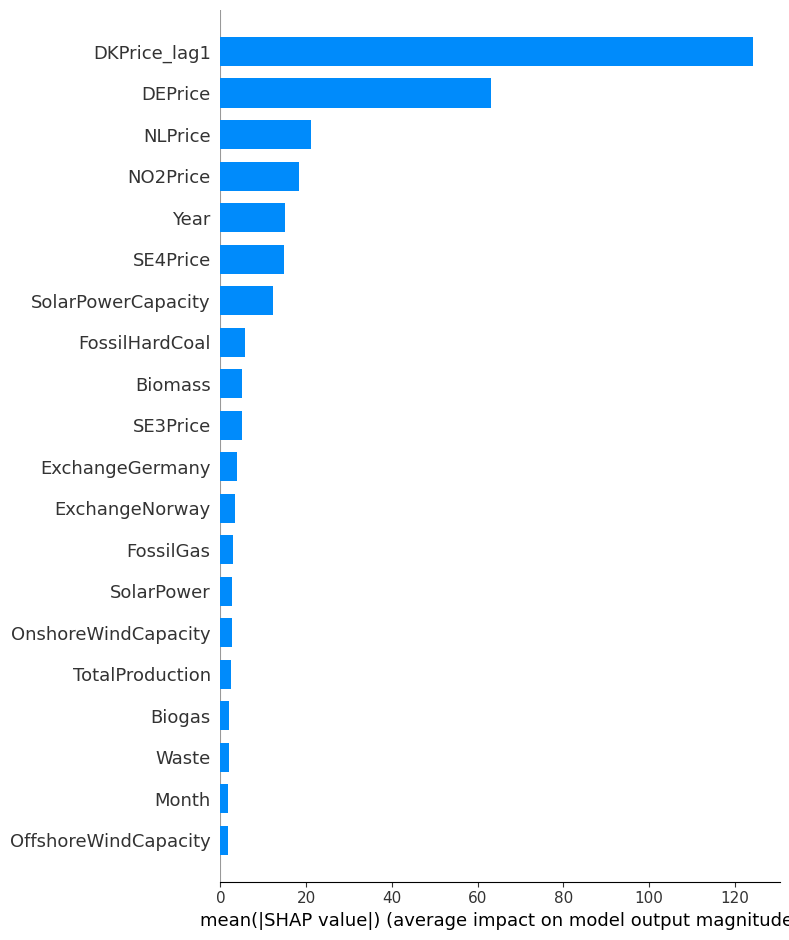

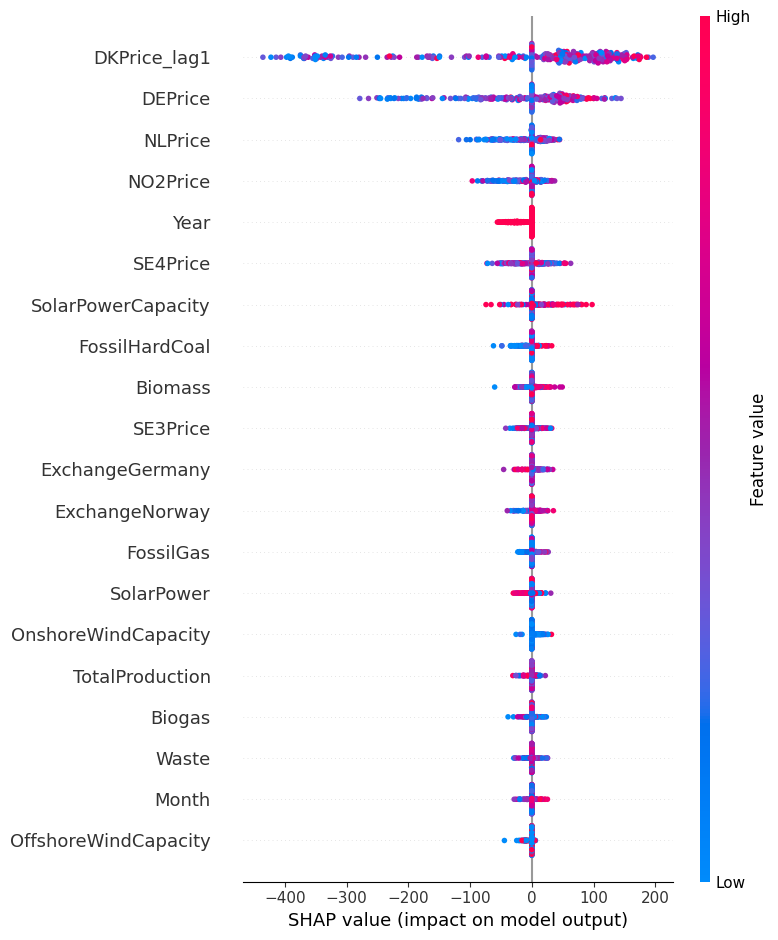

c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\torch\nn\modules\rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.lstm(


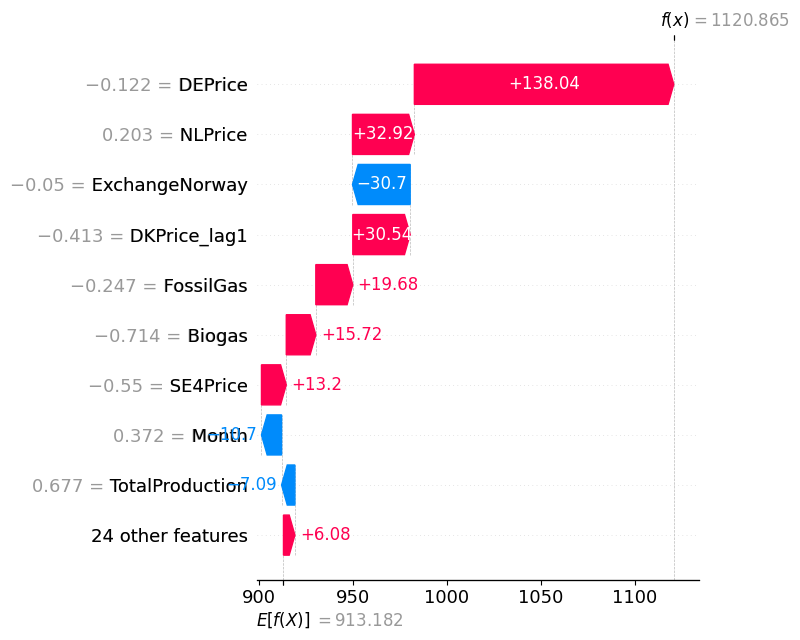

Available RAM after SHAP cleanup: 13.95 GB


predict_batch_size,8
shap_bg_size,200
shap_chunk_size,20
shap_eval_size,300
shap_feature_count,33
shap_grouped_feature_level,True
shap_sampling_unique_without_replacement,True
top_feature,DKPrice_lag1
top_feature_mean_abs_shap,124.36732


In [7]:
import gc
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import shap
import wandb
from shap.utils._legacy import DenseData

from Modules.week_predictions2 import (
    CAPACITY_FEATURES,
    FORECAST_METHODS,
    FORECASTABLE_FEATURES,
    KNOWN_FUTURE_FEATURES,
    WEATHER_FEATURES,
    _build_rnn_window,
    _categorize_feature_columns,
    _forecast_lag_feature_for_week,
    _forecast_last_known_value_for_week,
    _forecast_rf_feature_for_week,
    _forecast_skforecast_feature_for_week,
    _parse_lag_feature,
    _resolve_base_feature,
    _value_from_lag,
)

# ===========================
# SHAP configuration (LSTM)
# ===========================
quick_mode = False
n_eval_samples = 300        # number of unique random hours to explain from test set
bg_size = 200               # number of unique random background hours from train period
nsamples = 100              # SHAP Monte Carlo samples per explained point
shap_chunk_size = 20        # number of eval rows per SHAP call
predict_batch_size = 8      # model inference batch size inside predict_fn
include_beeswarm = True
include_waterfall = True

PRICE_ZONE = globals().get("PRICE_ZONE", "DK1")
WANDB_PROJECT = "LSTM final"
WANDB_RUN_NAME = f"{PRICE_ZONE}_LSTM_{TRAIN_WINDOW//8760}y_" + \
                 f"price_lag1{'incl' if INCLUDE_DKPRICE_LAG1_AS_INPUT else 'excl'}_2024" + \
                 f"{'incl' if INCLUDE_REMAINING_2024_DURING_TRAINING else 'excl'}" + \
                 f"_{PREDICT_PERIOD//168}val"
WANDB_RUN_NAME = "DK1_LSTM_2y_PricmaskExcl_PriceLag1Incl_2024Incl__4valhidden128_layers3"
WANDB_ARTIFACT_NAME = f"{WANDB_RUN_NAME}_model"
WANDB_SHAP_RUN_NAME = f"{WANDB_RUN_NAME}_SHAP"

if "dataset_train_input" not in globals() or dataset_train_input is None:
    raise ValueError("Missing dataset_train_input. Run the data loading cell first.")
if "dataset_test" not in globals() or dataset_test is None:
    raise ValueError("Missing dataset_test. Run the data loading cell first.")
if "df" not in globals() or df is None:
    raise ValueError("Missing df full timeline. Run the data loading cell first.")

# Features exactly as used during training.
target_col = "DKPrice"
feature_columns = [c for c in dataset_train_input.columns if c not in ["Time", target_col]]
if not feature_columns:
    raise ValueError("No feature columns found in dataset_train_input.")

# Build an evaluation dataset in the same format used by get_predictions: [target, Time, feature_columns].
test_source = dataset_test.copy().sort_values("Time").reset_index(drop=True)
history_source = df.loc[df["Time"] < test_source["Time"].min()].copy().sort_values("Time").reset_index(drop=True)
full_eval_dataset = (
    pd.concat([history_source, test_source], ignore_index=True)
    .sort_values("Time")
    .drop_duplicates(subset=["Time"], keep="last")
    .reset_index(drop=True)
)

# Ensure target-lag feature exists if required by feature_columns.
if "DKPrice_lag1" in feature_columns and "DKPrice_lag1" not in full_eval_dataset.columns:
    full_eval_dataset["DKPrice_lag1"] = full_eval_dataset[target_col].shift(1)

missing_in_eval = [c for c in feature_columns if c not in full_eval_dataset.columns]
if missing_in_eval:
    raise ValueError(f"full_eval_dataset is missing required feature columns: {missing_in_eval}")

full_eval_dataset = full_eval_dataset[[target_col, "Time"] + feature_columns].copy()
_categorize_feature_columns(feature_columns, target_col)

# Use same scaler setup as testing cell.
train_for_scaler = history_source.sort_values("Time").copy()
if "DKPrice_lag1" in feature_columns and "DKPrice_lag1" not in train_for_scaler.columns:
    train_for_scaler["DKPrice_lag1"] = train_for_scaler[target_col].shift(1)
train_for_scaler = train_for_scaler.tail(TRAIN_WINDOW).reset_index(drop=True)
X_scaler = train_for_scaler[feature_columns].astype(np.float32)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_scaler)

# Start dedicated W&B run and load trained model artifact.
wandb_run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_SHAP_RUN_NAME,
    job_type="shap-analysis",
    config={
        "price_zone": PRICE_ZONE,
        "artifact_name": WANDB_ARTIFACT_NAME,
        "n_eval_samples_requested": int(n_eval_samples),
        "bg_size_requested": int(bg_size),
        "nsamples": int(nsamples),
        "sampling": "random_unique_hours_no_replacement",
        "explanation_mode": "realistic_one_step_hour",
    },
    reinit=True,
    settings=wandb.Settings(start_method="thread"),
)

model_artifact = wandb_run.use_artifact(f"{WANDB_ARTIFACT_NAME}:latest")
artifact_dir = Path(model_artifact.download())
model_path = artifact_dir / "model.joblib"
if not model_path.exists():
    raise ValueError(f"Could not find model.joblib in downloaded artifact: {artifact_dir}")

model = joblib.load(model_path)
print(f"Loaded LSTM model artifact: {WANDB_ARTIFACT_NAME}:latest")

# Candidate timestamps: all test hours. We sample unique hours without replacement.
candidate_times = pd.to_datetime(test_source["Time"]).drop_duplicates().sort_values().reset_index(drop=True)
if len(candidate_times) == 0:
    raise ValueError("No candidate test hours found for SHAP evaluation.")

if quick_mode:
    n_eval_samples = min(80, len(candidate_times))
    bg_size = min(40, len(dataset_train_input))
    nsamples = 50
    shap_chunk_size = min(10, n_eval_samples)
    predict_batch_size = 4
else:
    n_eval_samples = min(int(n_eval_samples), len(candidate_times))
    bg_size = min(int(bg_size), len(dataset_train_input))
    shap_chunk_size = max(1, min(int(shap_chunk_size), n_eval_samples))
    predict_batch_size = max(1, int(predict_batch_size))

rng = np.random.default_rng(42)
eval_times = pd.to_datetime(rng.choice(candidate_times.values, size=n_eval_samples, replace=False))
eval_times = pd.Series(eval_times).drop_duplicates().sort_values().tolist()

train_candidate_times = pd.to_datetime(dataset_train_input["Time"]).dropna().drop_duplicates().sort_values().reset_index(drop=True)
if len(train_candidate_times) == 0:
    raise ValueError("No candidate train hours found for SHAP background.")
bg_size = min(bg_size, len(train_candidate_times))
bg_times = pd.to_datetime(rng.choice(train_candidate_times.values, size=bg_size, replace=False))
bg_times = pd.Series(bg_times).drop_duplicates().sort_values().tolist()

present_forecast_features = [
    feat for feat in FORECASTABLE_FEATURES if feat in full_eval_dataset.columns and feat != target_col
]
non_rf_features = [
    feat for feat in present_forecast_features
    if FORECAST_METHODS[PRICE_ZONE].get(feat) in {"lag24", "lag168", "last_known_value", "skforecast"}
]
rf_features = [
    feat for feat in present_forecast_features if FORECAST_METHODS[PRICE_ZONE].get(feat) == "rf"
]

def _clear_cuda_cache():
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass

def _build_one_hour_model_window(timestamp: pd.Timestamp):
    timestamp = pd.Timestamp(timestamp)
    history_df = full_eval_dataset.loc[full_eval_dataset["Time"] < timestamp].copy().reset_index(drop=True)
    if history_df.empty:
        raise ValueError(f"No history before timestamp {timestamp}.")

    block_true = full_eval_dataset.loc[full_eval_dataset["Time"] == timestamp].copy().reset_index(drop=True)
    if block_true.empty:
        raise ValueError(f"Timestamp {timestamp} is not present in full_eval_dataset.")

    block_df = pd.DataFrame({"Time": [timestamp]})

    # Seed with known/available feature values for this hour.
    for col in present_forecast_features:
        if col in block_true.columns:
            block_df[col] = block_true[col].to_numpy()

    if use_precomputed_feature_values and "feature_predictions" in globals() and feature_predictions is not None:
        preds_df = feature_predictions.copy()
        preds_df = preds_df.loc[:, ~preds_df.columns.duplicated()].copy()
        if "DKZone" in preds_df.columns:
            preds_df = preds_df.loc[preds_df["DKZone"] == PRICE_ZONE].copy()
        preds_df["Time"] = pd.to_datetime(preds_df["Time"], dayfirst=True)
        row_pre = preds_df.loc[preds_df["Time"] == timestamp]
        if len(row_pre) == 1:
            for col in present_forecast_features:
                if col in row_pre.columns:
                    block_df[col] = row_pre[col].to_numpy()

    for col in KNOWN_FUTURE_FEATURES + WEATHER_FEATURES + CAPACITY_FEATURES:
        if col in block_true.columns and col not in block_df.columns:
            block_df[col] = block_true[col].to_numpy()

    # Recreate feature-forecast behavior from get_predictions for this single hour.
    for feature_name in non_rf_features:
        if use_precomputed_feature_values and feature_name in block_df.columns and block_df[feature_name].notna().all():
            continue
        if (not USE_FORECASTED_HISTORY) and feature_name in block_df.columns and block_df[feature_name].notna().all():
            continue

        method = FORECAST_METHODS[PRICE_ZONE][feature_name]
        if method == "lag24":
            block_df[feature_name] = _forecast_lag_feature_for_week(history_df, block_df, feature_name, 24)
        elif method == "lag168":
            block_df[feature_name] = _forecast_lag_feature_for_week(history_df, block_df, feature_name, 168)
        elif method == "last_known_value":
            block_df[feature_name] = _forecast_last_known_value_for_week(history_df, feature_name, len(block_df))
        elif method == "skforecast":
            block_df[feature_name] = _forecast_skforecast_feature_for_week(
                history_df, block_df, feature_name, offset=168, n_offsets=3, agg_func=np.mean
            )
        else:
            raise ValueError(f"Unsupported forecast method '{method}' for {feature_name}.")

    for feature_name in rf_features:
        if use_precomputed_feature_values and feature_name in block_df.columns and block_df[feature_name].notna().all():
            continue
        if (not USE_FORECASTED_HISTORY) and feature_name in block_df.columns and block_df[feature_name].notna().all():
            continue

        if "rf_models" not in globals() or rf_models is None or not rf_models:
            continue
        block_df[feature_name] = _forecast_rf_feature_for_week(history_df, block_df, feature_name, PRICE_ZONE, rf_models)

    prepared_row = block_df.iloc[0].to_dict()
    new_row = {"Time": timestamp}
    for col in feature_columns:
        if col in prepared_row:
            new_row[col] = prepared_row[col]
            continue

        base_feature, lag_hours = _parse_lag_feature(col)
        if lag_hours is not None:
            resolved_base = _resolve_base_feature(base_feature, target_col)
            if resolved_base == target_col:
                tmp_block = pd.DataFrame({"Time": [timestamp], resolved_base: [np.nan]})
                new_row[col] = _value_from_lag(history_df, tmp_block, resolved_base, timestamp, lag_hours)
            else:
                new_row[col] = _value_from_lag(history_df, block_df, resolved_base, timestamp, lag_hours)
            continue

        raise ValueError(f"Could not build feature column '{col}' for timestamp {timestamp}.")

    seq_len = int(getattr(model, "sequence_length", 1))
    include_target_history = bool(getattr(model, "use_target_history", False))
    X_window = _build_rnn_window(
        history_rows=history_df,
        current_row=new_row,
        feature_columns=feature_columns,
        sequence_length=seq_len,
        target_col=target_col,
        include_target_history=include_target_history,
        fitted_scaler=scaler,
    )
    return X_window.astype(np.float32), new_row

# Build realistic one-step windows for evaluation and background samples.
X_eval_windows = []
used_eval_times = []
for t in eval_times:
    try:
        Xw, _ = _build_one_hour_model_window(t)
        X_eval_windows.append(Xw[0])
        used_eval_times.append(pd.Timestamp(t))
    except Exception as err:
        print(f"Skipping eval timestamp {t} due to: {err}")

X_bg_windows = []
used_bg_times = []
for t in bg_times:
    try:
        Xw, _ = _build_one_hour_model_window(t)
        X_bg_windows.append(Xw[0])
        used_bg_times.append(pd.Timestamp(t))
    except Exception as err:
        print(f"Skipping background timestamp {t} due to: {err}")

if len(X_eval_windows) == 0:
    raise RuntimeError("No valid evaluation windows were created for SHAP.")
if len(X_bg_windows) == 0:
    raise RuntimeError("No valid background windows were created for SHAP.")

X_eval_windows = np.asarray(X_eval_windows, dtype=np.float32)
X_bg_windows = np.asarray(X_bg_windows, dtype=np.float32)

n_eval, seq_len, n_in = X_eval_windows.shape
_, bg_seq_len, bg_n_in = X_bg_windows.shape
if seq_len != bg_seq_len or n_in != bg_n_in:
    raise ValueError("Evaluation and background window shapes do not match.")

# Flatten only for model IO. Grouping below ensures perturbation happens at base-feature level across time.
X_eval_flat = X_eval_windows.reshape(n_eval, seq_len * n_in)
X_bg_flat = X_bg_windows.reshape(len(X_bg_windows), seq_len * n_in)

base_input_names = list(feature_columns)
if bool(getattr(model, "use_target_history", False)):
    base_input_names += [f"{target_col}_hist", f"{target_col}_hist_mask"]
if len(base_input_names) != n_in:
    base_input_names = [f"f{i}" for i in range(n_in)]

# One SHAP feature group per base feature; each group spans all time steps.
groups = []
for j in range(n_in):
    groups.append([s * n_in + j for s in range(seq_len)])

def predict_fn(flat_x):
    arr = np.asarray(flat_x, dtype=np.float32)
    arr = arr.reshape(-1, seq_len, n_in)
    preds_chunks = []
    for start in range(0, len(arr), predict_batch_size):
        stop = min(start + predict_batch_size, len(arr))
        preds_part = model.predict(arr[start:stop])
        preds_chunks.append(np.asarray(preds_part).reshape(-1))
        _clear_cuda_cache()
    if preds_chunks:
        return np.concatenate(preds_chunks, axis=0)
    return np.array([], dtype=np.float32)

mem = psutil.virtual_memory()
print(f"Available RAM before SHAP: {mem.available / (1024**3):.2f} GB")
print(f"Unique eval hours requested: {n_eval_samples}")
print(f"Unique eval hours used: {len(used_eval_times)}")
print(f"Unique background hours used: {len(used_bg_times)}")
print(f"Window shape for SHAP: {X_eval_windows.shape}")
print(f"Grouped SHAP feature count: {len(base_input_names)}")
print(f"Kernel SHAP nsamples: {nsamples}")
print(f"SHAP chunk size: {shap_chunk_size}")
print(f"Predict batch size: {predict_batch_size}")

grouped_background = DenseData(X_bg_flat, base_input_names, groups)
explainer = shap.KernelExplainer(predict_fn, grouped_background)

shap_chunks = []
n_chunks = (len(X_eval_flat) + shap_chunk_size - 1) // shap_chunk_size
for idx, start in enumerate(range(0, len(X_eval_flat), shap_chunk_size), start=1):
    stop = min(start + shap_chunk_size, len(X_eval_flat))
    print(f"Computing SHAP chunk {idx}/{n_chunks} (rows {start}:{stop})...", flush=True)
    X_chunk = X_eval_flat[start:stop]
    shap_chunk = np.asarray(explainer.shap_values(X_chunk, nsamples=nsamples))
    shap_chunks.append(shap_chunk)
    _clear_cuda_cache()
    gc.collect()

shap_values = np.vstack(shap_chunks)
gc.collect()

print("\nSHAP analysis complete.")

# Build grouped display values (mean over the sequence window for each base feature).
X_eval_grouped = X_eval_windows.mean(axis=1)
X_eval_grouped_df = pd.DataFrame(X_eval_grouped, columns=base_input_names)

plt.figure(figsize=(13, 6))
shap.summary_plot(shap_values, X_eval_grouped_df, plot_type="bar", show=False)
plt.tight_layout()
wandb_run.log({"shap_bar_grouped_features": wandb.Image(plt.gcf())})
plt.show()
plt.close()

if include_beeswarm:
    plt.figure(figsize=(13, 8))
    shap.summary_plot(shap_values, X_eval_grouped_df, show=False)
    plt.tight_layout()
    wandb_run.log({"shap_beeswarm_grouped_features": wandb.Image(plt.gcf())})
    plt.show()
    plt.close()

if include_waterfall:
    i = 0
    base_value = float(np.mean(predict_fn(X_bg_flat)))
    explanation = shap.Explanation(
        values=shap_values[i],
        base_values=base_value,
        data=X_eval_grouped_df.iloc[i].values,
        feature_names=X_eval_grouped_df.columns.tolist(),
    )
    plt.figure(figsize=(12, 5))
    shap.plots.waterfall(explanation, show=False)
    plt.tight_layout()
    wandb_run.log({"shap_waterfall_grouped_features": wandb.Image(plt.gcf())})
    plt.show()
    plt.close()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": base_input_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

wandb_run.log({"shap_importance_table_grouped_features": wandb.Table(dataframe=importance_df)})
wandb_run.log({
    "shap_eval_hours": wandb.Table(dataframe=pd.DataFrame({"Time": used_eval_times})),
    "shap_bg_hours": wandb.Table(dataframe=pd.DataFrame({"Time": used_bg_times})),
})
wandb_run.summary.update({
    "shap_eval_size": int(len(used_eval_times)),
    "shap_bg_size": int(len(used_bg_times)),
    "shap_sampling_unique_without_replacement": True,
    "shap_grouped_feature_level": True,
    "shap_feature_count": int(len(base_input_names)),
    "shap_chunk_size": int(shap_chunk_size),
    "predict_batch_size": int(predict_batch_size),
    "top_feature": str(importance_df.iloc[0]["feature"]),
    "top_feature_mean_abs_shap": float(importance_df.iloc[0]["mean_abs_shap"]),
})

mem_after = psutil.virtual_memory()
print(f"Available RAM after SHAP cleanup: {mem_after.available / (1024**3):.2f} GB")

del X_eval_windows, X_bg_windows, X_eval_flat, X_bg_flat, shap_values
gc.collect()
_clear_cuda_cache()
wandb.finish()